# dcngen — DCN-Bench v1: worked examples

A guided look at the **released dataset** (`data/v1`): 3,016 labelled thermal-hydraulic
scenarios on the closed-loop Hanoi DCN, generated 2026-07-25/27 from master seed 42.

This notebook shows *examples* — what a scenario actually looks like, what each fault class
does to the physics, and two things a reader should know before training on it. For the
aggregate numbers use `scripts/dataset_statistics.py` (which also emits `\input`-ready
LaTeX tables).

**Contents**

1. What is in the dataset
2. A clean-normal day
3. The three fault classes, each against its scenario's own healthy consumers
4. Low-ΔT syndrome: why fouling and bypass are hard to tell apart
5. A caveat with a picture: the plant make-up channel gives leaks away
6. The 30-day tier
7. Dataset statistics for the write-up

Everything below reads only `data/v1/` — no re-simulation.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
V1 = ROOT / "data" / "v1"
assert V1.exists(), "generate the dataset first — this notebook only reads data/v1"

# Validated reference palette (dataviz skill; light mode, categorical checks pass).
# Colour follows the ENTITY — here the fault class — and never its rank, so a class
# keeps its hue in every figure below.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e8e7e3", "#fcfcfb"
CLASS_COLOR = {"normal": BLUE, "leak": ORANGE, "fouling": AQUA, "bypass": YELLOW}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True,  # grid behind the marks, never through them
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "figure.titlesize": 14,
    "legend.frameon": False, "figure.dpi": 110,
})

_FOLDER = re.compile(r"uid(\d+)$")


def folder(uid: int) -> Path:
    return V1 / f"uid{uid:05d}"


def card(uid: int) -> dict:
    return json.loads((folder(uid) / "card.json").read_text())


def table(uid: int, name: str) -> pd.DataFrame:
    return pd.read_parquet(folder(uid) / f"{name}.parquet")


def wide(uid: int, column: str) -> pd.DataFrame:
    """node_dynamics as a (timestep x junction) frame for one channel."""
    n = table(uid, "node_dynamics")
    return n.pivot(index="time_id", columns="junction", values=column)


def hours(uid: int, c: dict | None = None) -> np.ndarray:
    c = c or card(uid)
    return np.arange(c["n_steps"]) * c["dt"] / 3600.0


# One pass over the cards: cheap (JSON only, no Parquet) and the index for everything below.
records = []
for d in sorted(V1.glob("uid*")):
    if not _FOLDER.fullmatch(d.name):
        continue
    c = json.loads((d / "card.json").read_text())
    row, fault = c["plan"]["row"], c["fault"]
    records.append({
        "uid": c["scenario_id"], "tier": row["tier"], "cls": row["scenario_class"],
        "passed": c["validation"]["passed"], "n_steps": c["n_steps"],
        "severity": fault["severity"], "site": fault["location"],
        "whole_horizon": fault["whole_horizon"], "onset_step": fault["onset_step"],
        "T_ground": row["T_ground"], "T_supply": row["T_supply"],
        "draw": c["static_draw_id"],
    })
index = pd.DataFrame(records)
print(f"{len(index)} scenarios indexed · {index.passed.sum()} gate-passing "
      f"({index.passed.mean():.1%}) · {index.draw.nunique()} distinct static draws")

3016 scenarios indexed · 2880 gate-passing (95.5%) · 950 distinct static draws


## 1 · What is in the dataset

Three horizon tiers × four scenario classes. The bulk tier is the detection/localisation
workhorse; the week and month tiers exist so detection *delay* can be measured over a
realistic monitoring window.

Note that gate-failing scenarios are **kept**, with their verdicts, rather than dropped —
so the counts below are what was generated, and `passed` is a column you filter on
deliberately.

In [2]:
# One source of truth for every number below: the same module that emits the
# thesis's LaTeX tables. Re-deriving them here would let the notebook and the
# write-up drift apart.
import sys

sys.path.insert(0, str(ROOT / "scripts"))
import dataset_statistics as ds  # noqa: E402

CARDS = ds.load_cards(V1)
STATS = ds.summarise(CARDS, V1)
SAMPLER = CARDS[0]["config"]["sampler"]  # the config each record was generated under

shape = pd.DataFrame(
    {cls: {tier: STATS["shape"][(tier, cls)] for tier in ds.TIERS} for cls in ds.CLASSES}
).reindex(list(ds.TIERS))
shape.insert(0, "steps", [STATS["steps"][t][0] for t in shape.index])
shape.insert(1, "horizon", ["24 h", "7 d", "30 d"])
shape["gate"] = [
    f"{sum(STATS['gate_pass'][(t, c)] for c in ds.CLASSES)}"
    f"/{sum(STATS['shape'][(t, c)] for c in ds.CLASSES)}"
    for t in shape.index
]
shape.index.name = "tier"
shape

,steps,horizon,normal,leak,fouling,bypass,gate
tier,,,,,,,
bulk,144,24 h,1000,800,550,450,2672/2800
week,1008,7 d,80,50,40,30,193/200
month,4320,30 d,6,5,3,2,15/16


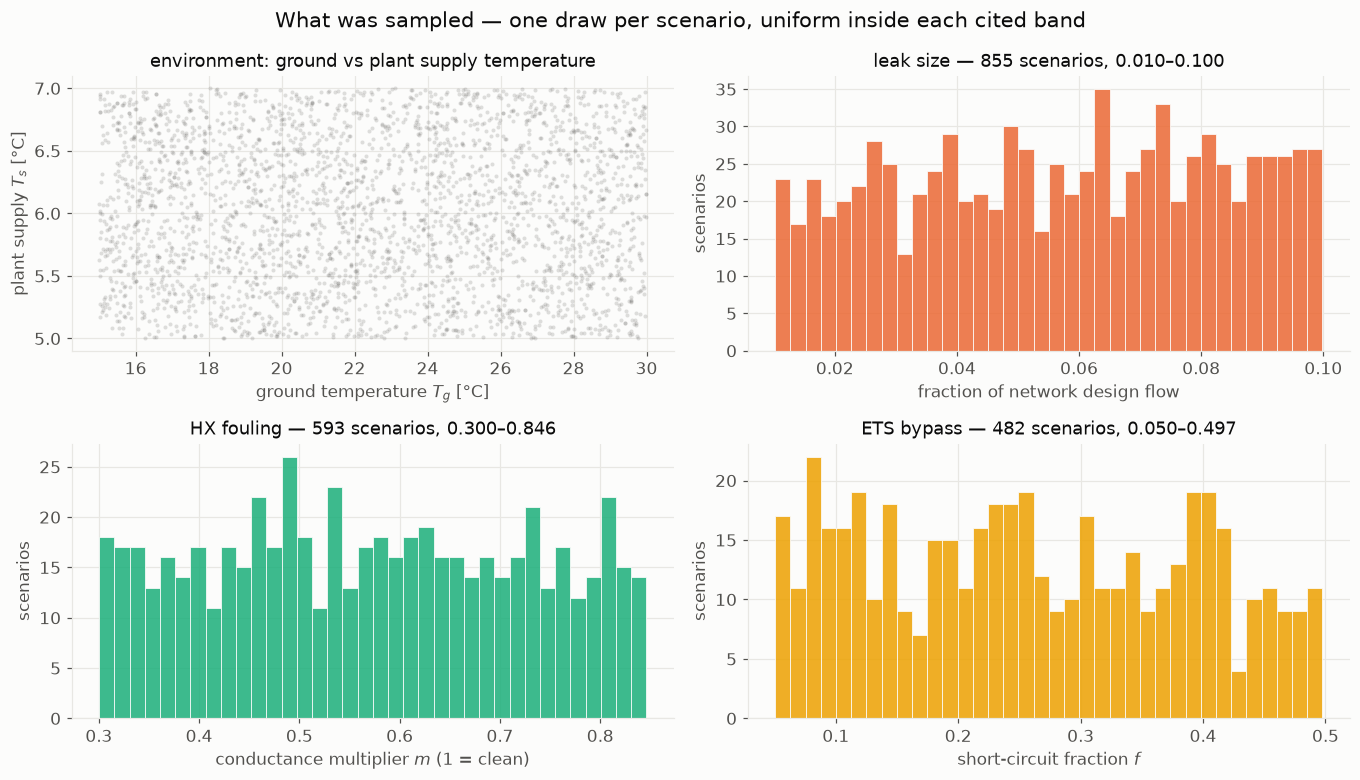

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.2))
fig.suptitle("What was sampled — one draw per scenario, uniform inside each cited band")

ax = axes[0, 0]
ax.scatter(index["T_ground"], index["T_supply"], s=7, color=INK2, alpha=0.18,
           linewidths=0)
ax.set_title("environment: ground vs plant supply temperature")
ax.set_xlabel("ground temperature $T_g$ [°C]")
ax.set_ylabel("plant supply $T_s$ [°C]")

for ax, cls, label, unit in (
    (axes[0, 1], "leak", "leak size", "fraction of network design flow"),
    (axes[1, 0], "fouling", "HX fouling", "conductance multiplier $m$ (1 = clean)"),
    (axes[1, 1], "bypass", "ETS bypass", "short-circuit fraction $f$"),
):
    v = index.loc[index.cls == cls, "severity"].dropna()
    ax.hist(v, bins=36, color=CLASS_COLOR[cls], alpha=0.85, edgecolor=SURFACE, linewidth=0.6)
    ax.set_title(f"{label} — {len(v)} scenarios, {v.min():.3f}–{v.max():.3f}")
    ax.set_xlabel(unit)
    ax.set_ylabel("scenarios")

fig.tight_layout()

The environment panel is the sampled box, not a correlation: `T_ground ~ U(15, 30) °C` and
`T_supply ~ U(5, 7) °C` are drawn independently. The band covers temperate-to-tropical
cooling markets — its lower edge is a *cooling-season floor*, not a Nordic annual mean
(dataset card §2.2).

The severity bands are each anchored in the source review rather than invented: fouling
stops at `m = 0.85` because milder fouling sits inside the plate-heat-exchanger design
margin and would not be a fault at all, and the bypass ceiling `f = 0.50` is the
literature's common worst case — plant ΔT at half of design.

## 2 · A clean-normal day

One bulk scenario, 144 steps of 10 minutes. Loads are per-consumer archetype profiles with
mean-one AR(1) noise; the hinge equation `ṁ = Q / (c_p·ΔT)` turns each load into the primary
flow its ETS valve requests. Supply temperature leaves the plant at the setpoint and warms
slightly on the way out — the ground is warmer than the water, so a *cooling* network gains
heat.

uid 3 · static draw 83 · T_supply 6.07 °C · T_ground 27.5 °C


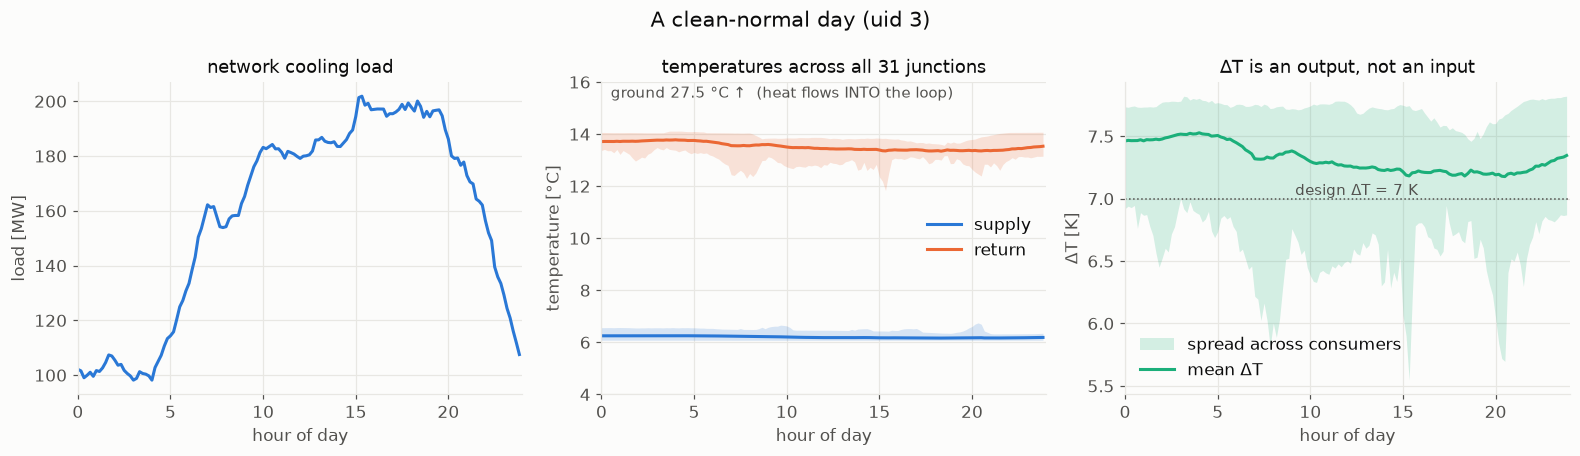

In [4]:
NORMAL = int(index[(index.tier == "bulk") & (index.cls == "normal") & index.passed].iloc[3]["uid"])
c = card(NORMAL)
h = hours(NORMAL, c)
row = c["plan"]["row"]
print(f"uid {NORMAL} · static draw {c['static_draw_id']} · "
      f"T_supply {row['T_supply']:.2f} °C · T_ground {row['T_ground']:.1f} °C")

load = wide(NORMAL, "cooling_load")
supply, ret, dT = wide(NORMAL, "supply_temp"), wide(NORMAL, "return_temp"), wide(NORMAL, "dT")
plant = table(NORMAL, "plant_dynamics").set_index("time_id")

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
fig.suptitle(f"A clean-normal day (uid {NORMAL})")

ax = axes[0]
ax.plot(h, load.sum(axis=1) / 1e6, color=BLUE, lw=2)
ax.set_title("network cooling load")
ax.set_xlabel("hour of day"); ax.set_ylabel("load [MW]"); ax.set_xlim(0, 24)

ax = axes[1]
ax.fill_between(h, supply.min(axis=1), supply.max(axis=1), color=BLUE, alpha=0.18, linewidth=0)
ax.fill_between(h, ret.min(axis=1), ret.max(axis=1), color=ORANGE, alpha=0.18, linewidth=0)
ax.plot(h, supply.mean(axis=1), color=BLUE, lw=2, label="supply")
ax.plot(h, ret.mean(axis=1), color=ORANGE, lw=2, label="return")
# The ground sits at 27.5 °C here — plotting it would squash the 6→13 °C detail
# this panel exists to show, so it is annotated instead of drawn to scale.
ax.set_ylim(4, 16)
ax.annotate(f"ground {row['T_ground']:.1f} °C ↑  (heat flows INTO the loop)",
            xy=(0.5, 15.4), color=INK2, fontsize=10)
ax.set_title("temperatures across all 31 junctions")
ax.set_xlabel("hour of day"); ax.set_ylabel("temperature [°C]"); ax.set_xlim(0, 24)
ax.legend(loc="center right")

ax = axes[2]
ax.fill_between(h, dT.min(axis=1), dT.max(axis=1), color=AQUA, alpha=0.18, linewidth=0,
                label="spread across consumers")
ax.plot(h, dT.mean(axis=1), color=AQUA, lw=2, label="mean ΔT")
ax.axhline(7.0, color=INK2, lw=1, ls=":")
ax.annotate("design ΔT = 7 K", xy=(12.5, 7.0), va="bottom", ha="center",
            color=INK2, fontsize=10)
ax.set_title("ΔT is an output, not an input")
ax.set_xlabel("hour of day"); ax.set_ylabel("ΔT [K]"); ax.set_xlim(0, 24)
ax.legend(loc="lower left")

fig.tight_layout()

The shaded bands are the min–max spread across the 31 consumers; the solid line is the mean.
ΔT hugs its 7 K design point but is never exactly on it — under ε-NTU the heat exchanger
returns whatever the flow, the arrival temperature and its conductance produce. That is the
whole reason low-ΔT faults are expressible in this dataset.

## 3 · The three fault classes

Each panel shows the channel where that fault actually speaks, against the **other consumers
in the same scenario** as a control (shaded 10–90th percentile band). Using a within-scenario
control matters: the released dataset contains no same-seed healthy twin of a faulted
scenario, so a cross-scenario comparison would confound the fault with a different draw.

leak uid 1071 · fouling uid 2316 · bypass uid 2742
fouled consumer: 46 of 144 steps with load unmet


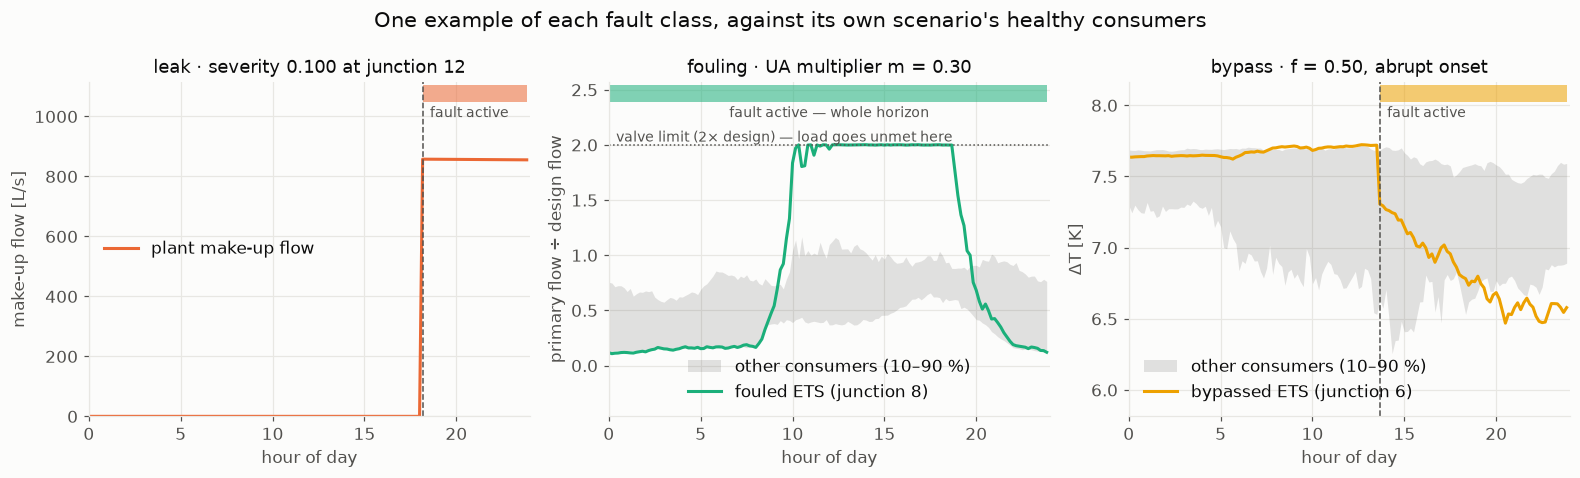

In [5]:
LEAK    = int(index[(index.tier == "bulk") & (index.cls == "leak") & index.passed]
              .nlargest(1, "severity").iloc[0]["uid"])
FOULING = int(index[(index.tier == "bulk") & (index.cls == "fouling") & index.passed]
              .nsmallest(1, "severity").iloc[0]["uid"])
BYPASS  = int(index[(index.tier == "bulk") & (index.cls == "bypass") & index.passed
                    & ~index.whole_horizon].nlargest(1, "severity").iloc[0]["uid"])

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
fig.suptitle("One example of each fault class, against its own scenario's healthy consumers")


def fault_ribbon(ax, uid, color):
    """Mark the labelled fault window as a ribbon ABOVE the data.

    Shading the plot area instead would collide with the grey peer band each
    panel already uses — two different greys meaning two different things.
    """
    m = table(uid, "labels")["fault_active"].to_numpy().astype(bool)
    h = hours(uid)
    ax.fill_between(h, 0.94, 0.99, where=m, transform=ax.get_xaxis_transform(),
                    color=color, alpha=0.55, linewidth=0, step="mid")
    ax.margins(y=0.30)
    if m.all():
        ax.annotate("fault active — whole horizon", xy=(0.5, 0.895),
                    xycoords="axes fraction", ha="center", color=INK2, fontsize=9)
        return True
    onset = h[m][0]
    ax.axvline(onset, color=INK2, lw=1, ls="--")
    # label sits with its ribbon, not at a fixed fraction of the axes
    ax.annotate("fault active", xy=(onset + 0.4, 0.895), xycoords=ax.get_xaxis_transform(),
                ha="left", color=INK2, fontsize=9)
    return False


PEER = "other consumers (10–90 %)"

# --- leak: the hydraulic signature, at the plant -------------------------------
ax, uid = axes[0], LEAK
c = card(uid); h = hours(uid, c)
p = table(uid, "plant_dynamics").set_index("time_id")
ax.plot(h, p["make_up_flow"] * 1e3, color=ORANGE, lw=2, label="plant make-up flow")
fault_ribbon(ax, uid, ORANGE)
ax.set_ylim(bottom=0)  # make-up flow cannot be negative; margins would imply it can
ax.set_title(f"leak · severity {c['fault']['severity']:.3f} at junction {c['fault']['location']}")
ax.set_xlabel("hour of day"); ax.set_ylabel("make-up flow [L/s]"); ax.set_xlim(0, 24)
ax.legend(loc="center left")

# --- fouling: the valve pulls more flow to chase the load ----------------------
ax, uid = axes[1], FOULING
c = card(uid); h = hours(uid, c); site = c["fault"]["location"]
flow = wide(uid, "consumer_flow")
design = table(uid, "node_static").set_index("junction")["design_flow"]
cap = c["config"]["ets"]["max_flow_factor"]
util = flow.div(design)
others = [j for j in util.columns if j != site]
ax.fill_between(h, util[others].quantile(0.1, axis=1), util[others].quantile(0.9, axis=1),
                color=INK2, alpha=0.16, linewidth=0, label=PEER)
ax.plot(h, util[site], color=AQUA, lw=2, label=f"fouled ETS (junction {site})")
ax.axhline(cap, color=INK2, lw=1, ls=":")
ax.annotate(f"valve limit ({cap:g}× design) — load goes unmet here",
            xy=(0.4, cap), va="bottom", color=INK2, fontsize=9)
whole = fault_ribbon(ax, uid, AQUA)
ax.set_title(f"fouling · UA multiplier m = {c['fault']['severity']:.2f}")
ax.set_xlabel("hour of day"); ax.set_ylabel("primary flow ÷ design flow"); ax.set_xlim(0, 24)
ax.legend(loc="lower center")

# --- bypass: ΔT steps down when the short-circuit opens ------------------------
ax, uid = axes[2], BYPASS
c = card(uid); h = hours(uid, c); site = c["fault"]["location"]
dTb = wide(uid, "dT")
others = [j for j in dTb.columns if j != site]
ax.fill_between(h, dTb[others].quantile(0.1, axis=1), dTb[others].quantile(0.9, axis=1),
                color=INK2, alpha=0.16, linewidth=0, label=PEER)
ax.plot(h, dTb[site], color=YELLOW, lw=2, label=f"bypassed ETS (junction {site})")
fault_ribbon(ax, uid, YELLOW)
ax.set_title(f"bypass · f = {c['fault']['severity']:.2f}, abrupt onset")
ax.set_xlabel("hour of day"); ax.set_ylabel("ΔT [K]"); ax.set_xlim(0, 24)
ax.legend(loc="lower left")

fig.tight_layout()
unmet_here = int(wide(FOULING, "unmet")[card(FOULING)["fault"]["location"]].sum())
print(f"leak uid {LEAK} · fouling uid {FOULING} · bypass uid {BYPASS}")
print(f"fouled consumer: {unmet_here} of {card(FOULING)['n_steps']} steps with load unmet")

Three different mechanisms, three different places to look:

- **Leak** is hydraulic and shows up at the *plant*: the loop is closed, so make-up flow is
  identically zero until an orifice opens. The shaded band is the labelled fault window.
- **Fouling** lowers the heat exchanger's conductance `UA`. The control valve compensates by
  pulling more primary flow to keep delivering the building's load — here well above the
  other consumers' utilisation, for the whole horizon. At the afternoon peak it runs into the
  valve's 2× limit and *still* cannot deliver: that consumer's load goes unmet for 46 of the
  144 steps. Unmet load under an active fault is signal, not a defect, and the gate scores it
  separately from unmet load on clean stretches.
- **Bypass** short-circuits a fraction `f` of primary flow around the exchanger. The returning
  water is a mix of heated and un-heated flow, so ΔT steps down the moment the fault opens.

Fouling and bypass are the two mechanisms of **low-ΔT syndrome**, the dominant district-cooling
pathology — which is exactly why telling them apart is the interesting task.

## 4 · Low-ΔT syndrome: fouling and bypass share a symptom

If the two faults were separable by their symptom, cause discrimination would be trivial.
They are not. Below, every point is one scenario's *faulted* consumer, placed by how far its
ΔT sits below its scenario's healthy consumers and how much extra flow it pulls.

flow-ratio range shared by BOTH classes: 0.58 – 2.13


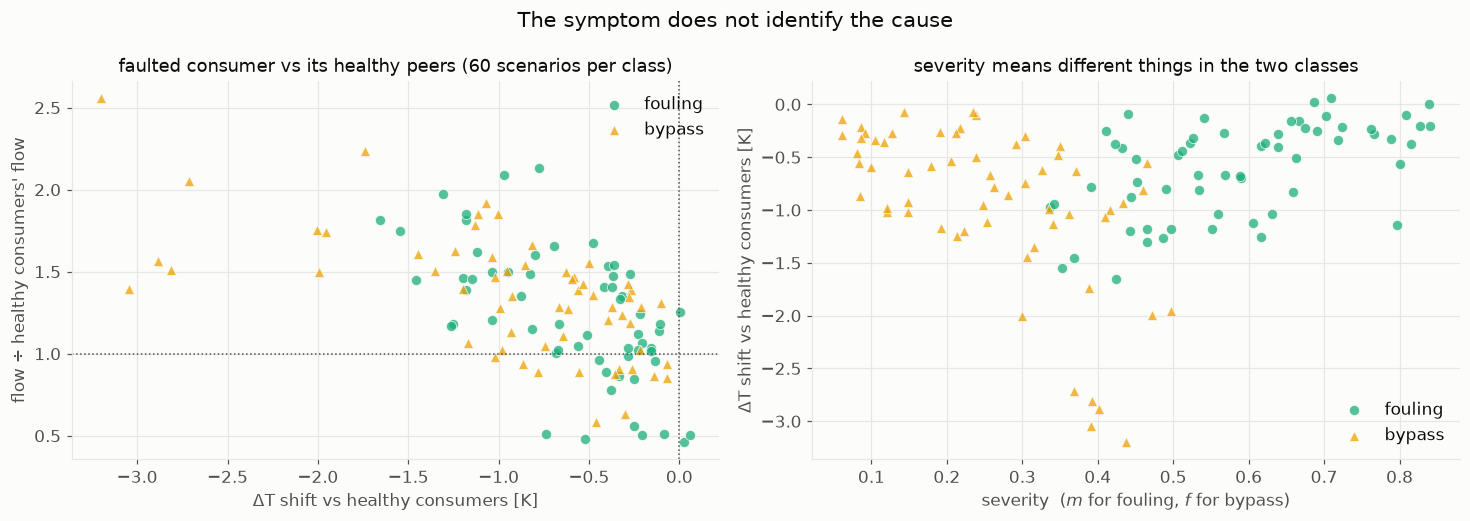

In [6]:
def faulted_vs_healthy(uid: int, site: str) -> dict:
    """Where the faulted consumer sits relative to its own scenario's healthy ones."""
    dTw = wide(uid, "dT")
    flow = wide(uid, "consumer_flow")
    design = table(uid, "node_static").set_index("junction")["design_flow"]
    util = flow.div(design)
    others = [j for j in dTw.columns if j != site]
    return {
        "dT_shift": float(dTw[site].mean() - dTw[others].mean().mean()),
        "flow_ratio": float(util[site].mean() / util[others].mean().mean()),
    }


SAMPLE = 60
points = []
for cls in ("fouling", "bypass"):
    picked = index[(index.tier == "bulk") & (index.cls == cls) & index.passed].head(SAMPLE)
    for uid, site, sev in zip(picked["uid"], picked["site"], picked["severity"]):
        points.append({"cls": cls, "severity": sev, **faulted_vs_healthy(int(uid), site)})
points = pd.DataFrame(points)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8))
fig.suptitle("The symptom does not identify the cause")

# Marker shape as well as hue: aqua↔yellow is the weakest adjacent pair in this
# palette under protanopia (ΔE 9.1 — passing, but the narrowest margin here), and
# these are the two series a reader most needs to tell apart.
MARK = {"fouling": "o", "bypass": "^"}

for cls in ("fouling", "bypass"):
    s = points[points.cls == cls]
    ax1.scatter(s["dT_shift"], s["flow_ratio"], s=44, color=CLASS_COLOR[cls],
                marker=MARK[cls], alpha=0.75, linewidths=0.6, edgecolors=SURFACE,
                label=cls)
ax1.axhline(1.0, color=INK2, lw=1, ls=":")
ax1.axvline(0.0, color=INK2, lw=1, ls=":")
ax1.set_title(f"faulted consumer vs its healthy peers ({SAMPLE} scenarios per class)")
ax1.set_xlabel("ΔT shift vs healthy consumers [K]")
ax1.set_ylabel("flow ÷ healthy consumers' flow")
ax1.legend(loc="upper right")

for cls in ("fouling", "bypass"):
    s = points[points.cls == cls]
    ax2.scatter(s["severity"], s["dT_shift"], s=44, color=CLASS_COLOR[cls],
                marker=MARK[cls], alpha=0.75, linewidths=0.6, edgecolors=SURFACE,
                label=cls)
ax2.set_title("severity means different things in the two classes")
ax2.set_xlabel("severity  ($m$ for fouling, $f$ for bypass)")
ax2.set_ylabel("ΔT shift vs healthy consumers [K]")
ax2.legend(loc="lower right")

fig.tight_layout()

lo = max(points[points.cls == "fouling"].flow_ratio.min(),
         points[points.cls == "bypass"].flow_ratio.min())
hi = min(points[points.cls == "fouling"].flow_ratio.max(),
         points[points.cls == "bypass"].flow_ratio.max())
print(f"flow-ratio range shared by BOTH classes: {lo:.2f} – {hi:.2f}")

The two clouds overlap heavily: a consumer pulling ~1.5× its peers' flow with a depressed ΔT
could be either fault. Separating them needs the *mechanism*, not the magnitude — a bypass
mixes un-heated primary water into the return, so its ΔT collapses while the exchanger itself
still performs; fouling degrades the exchanger, so the collapse tracks the load. Both are
labelled here, both are whole-horizon-capable, and the healthy-UA sizing margin
deliberately overlaps the mild end of the fouling band so that "UA looks low" is not a
give-away by itself.

Note the right-hand panel: `severity` is **not** a common scale. For fouling it is a
conductance multiplier where *smaller is worse*; for bypass a short-circuit fraction where
*larger is worse*. They are stored in one column because every scenario has exactly one
fault — do not treat the column as a single physical quantity.

## 5 · A caveat with a picture: the plant make-up channel gives leaks away

The dataset stores full physical ground truth by design — no sensor sparsity, no measurement
noise. One consequence is worth seeing rather than reading: in a closed loop, make-up flow is
*identically zero* unless water is escaping.

clean scenarios peak at 2.66e-15 m³/s (machine zero); leaks bottom out at 8.89e-02 m³/s
separating gap: 3.3e+13×


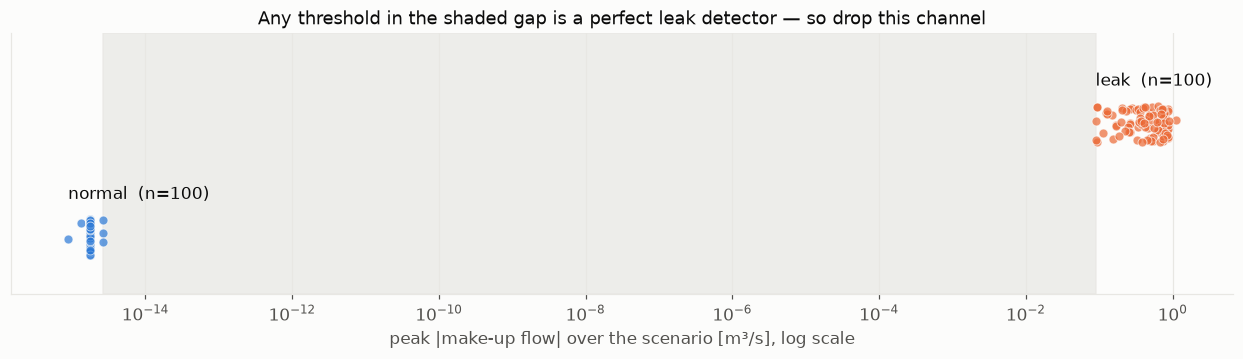

In [7]:
SAMPLE = 100
peak = []
for cls in ("normal", "leak"):
    picked = index[(index.tier == "bulk") & (index.cls == cls) & index.passed].head(SAMPLE)
    for uid in picked["uid"]:
        p = table(int(uid), "plant_dynamics")
        peak.append({"cls": cls, "peak": float(np.abs(p["make_up_flow"]).max())})
peak = pd.DataFrame(peak)

fig, ax = plt.subplots(figsize=(11.5, 3.4))
rng = np.random.default_rng(0)
for i, cls in enumerate(("normal", "leak")):
    v = peak.loc[peak.cls == cls, "peak"].to_numpy()
    ax.scatter(v, i + rng.uniform(-0.16, 0.16, v.size), s=34, color=CLASS_COLOR[cls],
               alpha=0.7, linewidths=0.6, edgecolors=SURFACE)
    ax.annotate(f"{cls}  (n={v.size})", xy=(v.min(), i + 0.34), color=INK,
                fontsize=11, ha="left")

gap_lo = peak.loc[peak.cls == "normal", "peak"].max()
gap_hi = peak.loc[peak.cls == "leak", "peak"].min()
ax.axvspan(gap_lo, gap_hi, color=GRID, alpha=0.7, zorder=0)
ax.set_xscale("log")
ax.set_xlim(peak["peak"].min() / 6, peak["peak"].max() * 6)  # room for the labels
ax.set_yticks([]); ax.set_ylim(-0.5, 1.8)
ax.set_xlabel("peak |make-up flow| over the scenario [m³/s], log scale")
ax.set_title("Any threshold in the shaded gap is a perfect leak detector — so drop this channel")
fig.tight_layout()

print(f"clean scenarios peak at {gap_lo:.2e} m³/s (machine zero); "
      f"leaks bottom out at {gap_hi:.2e} m³/s")
print(f"separating gap: {gap_hi / gap_lo:.1e}×")

Roughly **thirteen orders of magnitude** separate the two populations, with no overlap. A
detector that sees `make_up_flow` is doing a lookup, not learning; the same holds for
`leak_flow`, which *is* the realised ground truth.

**Any leak experiment must drop both channels**, or push them through a sensor model first.
They ship because the dataset stores ground truth, not because they are legitimate inputs
(dataset card §4). If a leak-detection F1 lands near 1.0, check this first.

## 6 · The 30-day tier

The long-horizon tier exists so detection *delay* can be measured over a realistic monitoring
window, and it is the only tier where the seasonal knob is active. A month-long record starts
at a uniformly drawn phase of the annual cycle — there is no synthetic calendar behind it


Be careful what you claim from this: 30 days is about 8 % of the annual cycle, so what the
figure shows is the diurnal cycle, the weekday/weekend rhythm, and a *slow drift* — not a
seasonal swing. Seeing a full seasonal excursion needs year-long records, which were
rescoped out of v1 to fit the submission window and are named as future work.

seasonal amplitude 0.41 · daily-mean load 130–150 MW


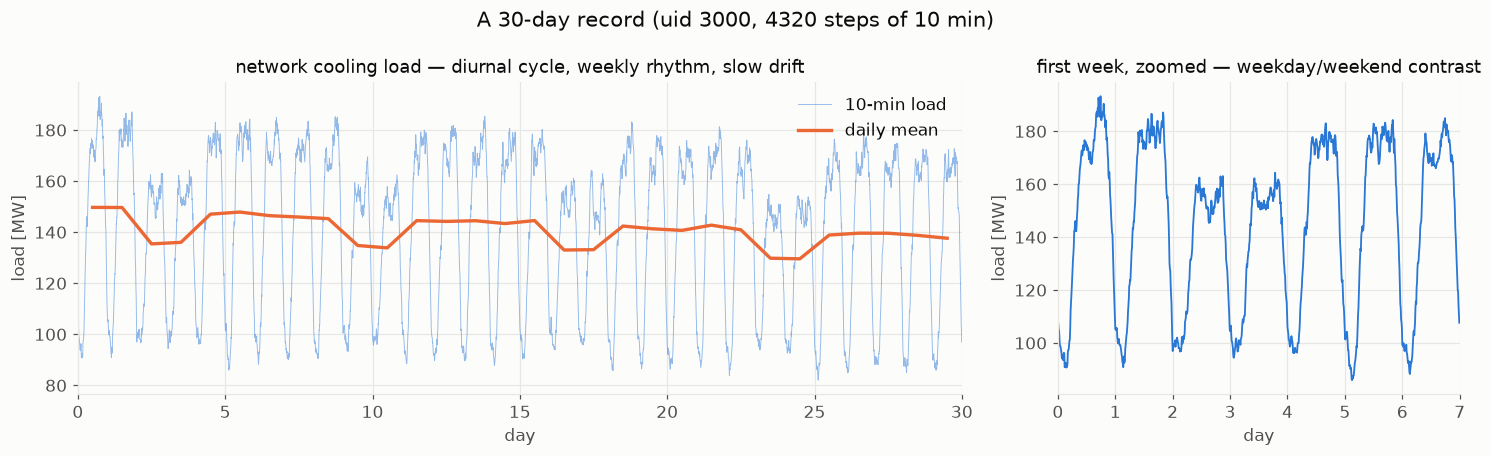

In [8]:
MONTH = int(index[(index.tier == "month") & (index.cls == "normal") & index.passed].iloc[0]["uid"])
c = card(MONTH)
days = np.arange(c["n_steps"]) * c["dt"] / 86400.0
total = wide(MONTH, "cooling_load").sum(axis=1).to_numpy() / 1e6
daily = pd.Series(total).groupby(np.arange(total.size) // 144).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.2),
                               gridspec_kw={"width_ratios": [2.2, 1]})
fig.suptitle(f"A 30-day record (uid {MONTH}, {c['n_steps']} steps of 10 min)")

ax1.plot(days, total, color=BLUE, lw=0.6, alpha=0.5, label="10-min load")
ax1.plot(daily.index + 0.5, daily.to_numpy(), color=ORANGE, lw=2.2, label="daily mean")
ax1.set_title("network cooling load — diurnal cycle, weekly rhythm, slow drift")
ax1.set_xlabel("day"); ax1.set_ylabel("load [MW]"); ax1.set_xlim(0, 30)
ax1.legend(loc="upper right")

first_week = total[: 7 * 144]
ax2.plot(np.arange(first_week.size) * 10 / 60 / 24, first_week, color=BLUE, lw=1.2)
ax2.set_title("first week, zoomed — weekday/weekend contrast")
ax2.set_xlabel("day"); ax2.set_ylabel("load [MW]"); ax2.set_xlim(0, 7)

fig.tight_layout()
print(f"seasonal amplitude {c['plan']['row']['seasonal_amplitude']:.2f} · "
      f"daily-mean load {daily.min():.0f}–{daily.max():.0f} MW")

## 7 · Dataset statistics for the write-up

Everything the methodology chapter needs to quote, from the same module that writes
`tables/*.tex`. Regenerate the dataset and these move with it — that is the point of
computing them rather than transcribing them.

In [9]:
print(f"network            {STATS['network']}")
print(f"timestep           {STATS['dt']:.0f} s")
print(f"graph              {STATS['junctions']} junctions ×2 (+2 plant headers), "
      f"{STATS['pipes']} pipes ×2, {STATS['consumers']} ETS crossovers")
print(f"scenarios          {STATS['n']}")
print(f"static draws used  {STATS['draws']} of {SAMPLER['static_draw_count']} available")
print(f"size on disk       {STATS['bytes'] / 2**30:.1f} GiB")
print(f"master seed        {STATS['seed']}  ({STATS['bitgen']}, numpy {STATS['numpy']})")

network            hanoi_8GB_1Y
timestep           600 s
graph              31 junctions ×2 (+2 plant headers), 34 pipes ×2, 31 ETS crossovers
scenarios          3016
static draws used  950 of 1000 available
size on disk       3.6 GiB
master seed        42  (PCG64, numpy 2.5.1)


In [10]:
# --- gate outcome per scenario class -------------------------------------------
gate_rows = []
for cls in ds.CLASSES:
    n = sum(STATS["shape"][(t, cls)] for t in ds.TIERS)
    p = sum(STATS["gate_pass"][(t, cls)] for t in ds.TIERS)
    gate_rows.append({"class": cls, "generated": n, "gate-passing": p,
                      "rate": f"{p / n:.1%}"})
total_n, total_p = sum(STATS["shape"].values()), sum(STATS["gate_pass"].values())
gate_rows.append({"class": "all", "generated": total_n, "gate-passing": total_p,
                  "rate": f"{total_p / total_n:.1%}"})
gate_table = pd.DataFrame(gate_rows).set_index("class")

print("failing rules (a scenario may trip more than one):", dict(STATS["rule_fail"]))
gate_table

failing rules (a scenario may trip more than one): {'convergence_budget': 114, 'unmet_load': 24, 'pressure_rails': 9}


,generated,gate-passing,rate
class,,,
normal,1086,1036,95.4%
leak,855,814,95.2%
fouling,593,572,96.5%
bypass,482,458,95.0%
all,3016,2880,95.5%


In [11]:
# --- worst-case physics, over the GATE-PASSING release -------------------------
# Budgeted quantities exclude the rejects on purpose: a worst case taken from a
# scenario that failed the gate describes something nobody will train on.
residuals = pd.DataFrame([
    {"quantity": "first-law energy residual (all scenarios)",
     "worst case": f"{max(STATS['energy'], default=0):.2e}",
     "note": "exact to machine precision"},
    {"quantity": "unconverged timesteps",
     "worst case": f"{max(STATS['unconverged_ok'], default=0):.2%}",
     "note": "budget 2 %, gate-passing only"},
    {"quantity": "unmet load on clean stretches",
     "worst case": f"{max(STATS['unmet_clean_ok'], default=0):.2%}",
     "note": "budget 0.5 %, gate-passing only"},
    {"quantity": "scenarios escalated to the PN25 class",
     "worst case": str(STATS["pn25"]), "note": f"of {total_n}"},
    {"quantity": "plant anchored at the rail fallback",
     "worst case": str(STATS["anchoring"].get("rail_fallback", 0)),
     "note": f"of {total_n}"},
]).set_index("quantity")
residuals

,worst case,note
quantity,,
first-law energy residual (all scenarios),4.23e-16,exact to machine precision
unconverged timesteps,1.98%,"budget 2 %, gate-passing only"
unmet load on clean stretches,0.47%,"budget 0.5 %, gate-passing only"
scenarios escalated to the PN25 class,407,of 3016
plant anchored at the rail fallback,80,of 3016


In [12]:
# --- realised sampling and fault characteristics -------------------------------
sampled = pd.DataFrame([
    {"quantity": "plant supply temperature $T_s$", "unit": "°C",
     "realised range": ds.rng(STATS["sampled"]["T_supply"])},
    {"quantity": "ground temperature $T_g$", "unit": "°C",
     "realised range": ds.rng(STATS["sampled"]["T_ground"])},
    {"quantity": "PUR conductivity", "unit": "W/(m·K)",
     "realised range": ds.rng(STATS["sampled"]["lambda_pur"])},
    {"quantity": "soil conductivity", "unit": "W/(m·K)",
     "realised range": ds.rng(STATS["sampled"]["lambda_soil"])},
    {"quantity": "burial cover", "unit": "m",
     "realised range": ds.rng(STATS["sampled"]["burial_cover"])},
]).set_index("quantity")

faults = pd.DataFrame([
    {"class": kind,
     "severity range": ds.rng(STATS["severity"][kind]),
     "whole-horizon": STATS["whole_horizon"][(kind, True)],
     "abrupt onset": STATS["whole_horizon"][(kind, False)],
     "distinct sites": len(STATS["fault_sites"][kind])}
    for kind in ("leak", "fouling", "bypass")
]).set_index("class")

print(f"abrupt onsets fall at {ds.rng(STATS['onset_frac'])} of the horizon")
print(f"archetype assignments (consumer-scenarios): {dict(STATS['archetypes'])}")
display(sampled)
faults

abrupt onsets fall at 0.2014--0.7996 of the horizon
archetype assignments (consumer-scenarios): {'retail': 19127, 'hotel': 19004, 'residential': 36192, 'office': 19173}


,unit,realised range
quantity,,
plant supply temperature $T_s$,°C,5.002--6.998
ground temperature $T_g$,°C,15--30
PUR conductivity,W/(m·K),0.023--0.029
soil conductivity,W/(m·K),1--1.6
burial cover,m,0.6--1.2


,severity range,whole-horizon,abrupt onset,distinct sites
class,,,,
leak,0.01021--0.09984,0,855,31
fouling,0.3004--0.846,593,0,31
bypass,0.05042--0.4974,241,241,31


Two cautions when quoting the fault table. `severity` is stored in one column but is a
different quantity per class — a UA multiplier for fouling (smaller is worse), a
short-circuit fraction for bypass and a fraction of network design flow for leaks
(larger is worse in both). And every class visits all 31 consumer sites, so a random
train/test split will put the *same* fault location on both sides: split by `uid` and
check location coverage.

The next cell rewrites `tables/*.tex` from exactly these numbers.

In [13]:
ds.latex_tables(STATS, ROOT / "tables")


wrote /home/asgerp/dcn-benchmark/tables/dataset-shape.tex, /home/asgerp/dcn-benchmark/tables/dataset-sampling.tex, /home/asgerp/dcn-benchmark/tables/dataset-gate.tex, /home/asgerp/dcn-benchmark/tables/dataset-residuals.tex


## Where to go next

- **`scripts/dataset_statistics.py`** — every aggregate number, plus `\input`-ready LaTeX
  tables. Regenerate rather than transcribe.
- **`dcngen.records.pyg_dataset.load_scenario`** — loads any folder above as a typed
  PyTorch-Geometric `HeteroData` graph (supply/return node types paired by index, directed
  pipe edges, ETS crossover edges, the plant edge closing the loop).
- **`notebooks/poc_overview.ipynb`** — the pipeline tour: topology, the supply/return mirror,
  the per-timestep solve, and the validation gate.

Three things to decide before training, all of them stated rather than defaulted: drop
`make_up_flow` / `leak_flow` for leak tasks (§5); include or exclude the gate-failing
scenarios (§1); and split by `uid` with fault-location coverage checked in every split —
scenarios share static draws and fault sites, so a naive random split leaks.